# Day 27 - Customer Machine Learning Foundation

## 학습 목적

통계 분석과 머신러닝의 차이를 이해하고,
현재 고객 데이터를 머신러닝 문제로 사용할 수 있는지 검토한다.

회귀와 분류, Feature와 Target,
데이터 누수, Train/Test 분할과 기준선의 개념을 학습한다.

현재 고객 데이터는 30명 수준의 학습용 가상 데이터이며,
retention_priority 역시 현재 주문 정보를 이용해 만든 규칙이다.

따라서 오늘은 모델 성능을 만드는 것이 아니라
머신러닝 문제를 올바르게 설계하는 데 집중한다.

## 분석 질문

1. 머신러닝과 기존 통계 분석의 질문은 어떻게 다른가?
2. 회귀와 분류는 무엇을 기준으로 구분하는가?
3. Feature와 Target은 무엇인가?
4. 현재 고객 데이터에서 데이터 누수가 발생할 수 있는 변수는 무엇인가?
5. Train/Test 데이터를 왜 분리해야 하는가?
6. 분류 문제에서 클래스 비율을 유지하며 분할하려면 어떻게 하는가?
7. 복잡한 모델을 만들기 전에 어떤 기준선과 비교해야 하는가?

## 주요 개념

### 회귀

연속적인 숫자를 예측한다.

예:
- 매출
- 주문 수
- 배송시간

### 분류

범주 또는 클래스 확률을 예측한다.

예:
- 이탈 / 유지
- 구매 / 미구매

### Feature

예측에 사용하는 입력 변수다.

Python에서는 일반적으로 X라고 표현한다.

### Target

모델이 예측해야 하는 정답이다.

Python에서는 일반적으로 y라고 표현한다.

### 데이터 누수

실제 예측 시점에 알 수 없는 정보나
Target을 직접 만드는 데 사용한 정보가
Feature에 포함되는 문제다.

In [1]:
# 라이브러리와 경로
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split


project_root = Path.cwd().parent

input_path = (
    project_root
    / "outputs"
    / "customer_order_mini_project.csv"
)

output_dir = (
    project_root
    / "outputs"
)

output_dir.mkdir(
    parents=True,
    exist_ok=True
)

print(input_path)
print(input_path.exists())

d:\Study\Projects\00_foundation_review\outputs\customer_order_mini_project.csv
True


In [2]:
# 데이터 불러오기
df = pd.read_csv(
    input_path
)

print(df.shape)

print(df.head())

(30, 18)
   customer_id customer_name   region grade  total_order_count  \
0            1           Kim    Seoul   VIP                  9   
1            5           Han    Seoul   VIP                  8   
2            6          Jung    Busan  GOLD                  7   
3            9          Yoon  Daejeon   VIP                  6   
4           25           Bae  Incheon   VIP                  6   

   paid_order_count  cancelled_order_count  paid_rate first_order_date  \
0                 9                      0      100.0       2026-01-15   
1                 8                      0      100.0       2025-12-20   
2                 6                      1       85.7       2026-01-05   
3                 6                      0      100.0       2026-01-07   
4                 6                      0      100.0       2026-01-12   

  last_order_date data_reference_date  active_period_days  \
0      2026-07-30          2026-07-31               196.0   
1      2026-07-31          

In [3]:
# 열 확인
print(df.columns)

Index(['customer_id', 'customer_name', 'region', 'grade', 'total_order_count',
       'paid_order_count', 'cancelled_order_count', 'paid_rate',
       'first_order_date', 'last_order_date', 'data_reference_date',
       'active_period_days', 'avg_days_between_orders', 'recency_days',
       'avg_customer_order_count', 'order_count_rank', 'activity_status',
       'management_action'],
      dtype='str')


## Target 정의

이번 실습에서는 머신러닝 데이터 분할을 연습하기 위해

management_action == "retention_priority"

인 고객을 True로 정의한다.

다만 이 Target은 실제 미래 이탈 결과가 아니라
현재 주문 데이터를 이용해 만든 업무 규칙이다.

따라서 실제 머신러닝 모델 성능을 평가하기 위한
좋은 Target이라고 보기는 어렵다.

In [4]:
# Target 생성
df["is_retention"] = (
    df["management_action"] == "retention_priority"
)

print(
    df["is_retention"]
    .value_counts()
)

is_retention
False    21
True      9
Name: count, dtype: int64


In [11]:
# Target 분포 요약
retention_count = (
    df["is_retention"]
    .sum()
)

other_count = (
    len(df) - retention_count
)

target_summary_df = pd.DataFrame(
    {
        "target" : [
            "Other",
            "Retention"
        ],
        "customer_count" : [
            other_count,
            retention_count
        ]
    }
)

print(target_summary_df)

      target  customer_count
0      Other              21
1  Retention               9


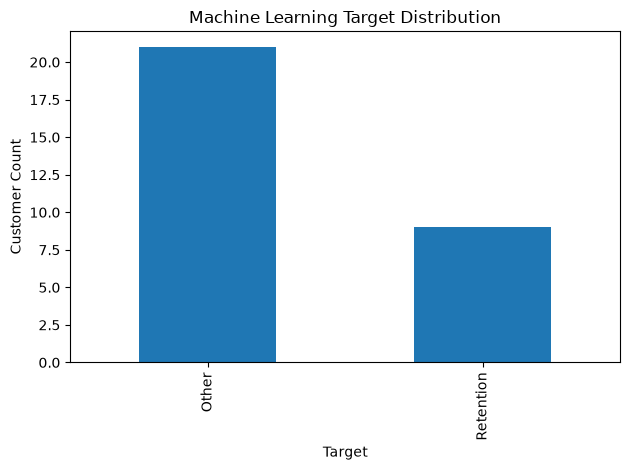

In [13]:
# Target 분포 그래프
figure_path = (
    output_dir
    / "customer_ml_target_distribution.png"
)

target_summary_df.plot.bar(
    x = "target",
    y = "customer_count",
    legend = False
)

plt.title(
    "Machine Learning Target Distribution"
)

plt.xlabel(
    "Target"
)

plt.ylabel(
    "Customer Count"
)

plt.tight_layout()

plt.savefig(
    figure_path,
    dpi = 300,
    bbox_inches = "tight"
)

plt.show()

## Feature 검토

숫자형 열이라고 해서 모두 Feature로 사용할 수 있는 것은 아니다.

Feature를 선택할 때는 다음을 확인한다.

1. 예측 시점에 실제로 알 수 있는가?
2. Target을 만드는 데 직접 사용된 변수인가?
3. Target 정보를 간접적으로 포함하는 파생 변수인가?
4. 단순 고객 ID처럼 예측 의미가 없는 값인가?

In [14]:
# Feature 검토표
feature_review_df = pd.DataFrame(
    {
        "column": [
            "customer_id",
            "customer_name",
            "grade",
            "region",
            "total_order_count",
            "paid_order_count",
            "cancelled_order_count",
            "paid_rate",
            "active_period_days",
            "avg_days_between_orders",
            "recency_days",
            "activity_status",
            "order_count_rank",
            "avg_customer_order_count",
            "management_action",
        ],
        "review": [
            "exclude",
            "exclude",
            "candidate",
            "candidate",
            "leakage",
            "caution",
            "candidate",
            "candidate",
            "candidate",
            "candidate",
            "leakage",
            "leakage",
            "leakage",
            "leakage",
            "target",
        ],
        "reason": [
            "identifier",
            "identifier",
            "definition_and_timing_check_needed",
            "candidate_feature",
            "used_to_define_target",
            "strongly_related_to_total_order_count",
            "candidate_feature",
            "candidate_feature",
            "candidate_feature",
            "candidate_feature",
            "used_to_define_target",
            "derived_from_recency_days",
            "derived_from_total_order_count",
            "used_as_target_rule_threshold",
            "source_of_target",
        ],
    }
)

print(
    feature_review_df
)

                      column     review                                 reason
0                customer_id    exclude                             identifier
1              customer_name    exclude                             identifier
2                      grade  candidate     definition_and_timing_check_needed
3                     region  candidate                      candidate_feature
4          total_order_count    leakage                  used_to_define_target
5           paid_order_count    caution  strongly_related_to_total_order_count
6      cancelled_order_count  candidate                      candidate_feature
7                  paid_rate  candidate                      candidate_feature
8         active_period_days  candidate                      candidate_feature
9    avg_days_between_orders  candidate                      candidate_feature
10              recency_days    leakage                  used_to_define_target
11           activity_status    leakage             

In [15]:
# Featuer 검토표 저장
feature_review_output_path = (
    output_dir
    / "customer_ml_feature_review.csv"
)

feature_review_df.to_csv(
    feature_review_output_path,
    index = False
)

print(
    feature_review_output_path.exists()
)

True


## Train/Test 분할용 Feature

오늘은 실제 모델 학습이 목적이 아니므로
누수 위험이 상대적으로 낮은 일부 변수만 사용하여
Train/Test 분할 구조를 연습한다.

사용 Feature:

- grade
- region
- cancelled_order_count
- paid_rate
- active_period_days
- avg_days_between_orders

범주형 변수와 결측값은
실제 모델 학습 전에 별도 전처리가 필요하다.

오늘은 데이터를 나누는 것까지만 진행한다.

In [16]:
# X와 y 생성
feature_columns = [
    "grade",
    "region",
    "cancelled_order_count",
    "paid_rate",
    "active_period_days",
    "avg_days_between_orders"
]

X = df[
    feature_columns
]

y = df[
    "is_retention"
]

print(X.shape)
print(y.shape)
print(X.head())
print(y.head())

(30, 6)
(30,)
  grade   region  cancelled_order_count  paid_rate  active_period_days  \
0   VIP    Seoul                      0      100.0               196.0   
1   VIP    Seoul                      0      100.0               223.0   
2  GOLD    Busan                      1       85.7               200.0   
3   VIP  Daejeon                      0      100.0               203.0   
4   VIP  Incheon                      0      100.0               200.0   

   avg_days_between_orders  
0                     24.5  
1                     31.9  
2                     33.3  
3                     40.6  
4                     40.0  
0    True
1    True
2    True
3    True
4    True
Name: is_retention, dtype: bool


In [17]:
# 결측치 확인
print(
    X.isna().sum()
)

grade                      0
region                     0
cancelled_order_count      0
paid_rate                  0
active_period_days         6
avg_days_between_orders    6
dtype: int64


## Train/Test 데이터 분할

Train 데이터는 모델이 패턴을 학습하는 데 사용한다.

Test 데이터는 모델이 학습 과정에서 보지 못한 데이터로,
최종적으로 새로운 데이터에서의 성능을 확인하기 위해 사용한다.

분류 문제에서는 Train과 Test의 Target 비율이
지나치게 달라지지 않도록 stratify를 사용할 수 있다.

In [19]:
# Train/Test 분할
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.25,
    random_state = 42,
    stratify = y
)

print(
    "X_train:",
    X_train.shape
)

print(
    "X_test:",
    X_test.shape
)

print(
    "y_train:",
    y_train.shape
)

print(
    "y_test:",
    y_test.shape
)

X_train: (22, 6)
X_test: (8, 6)
y_train: (22,)
y_test: (8,)


In [20]:
# Target 비율 확인
all_retention_rate = (
    y.mean()
)

train_retention_rate = (
    y_train.mean()
)

test_retention_rate = (
    y_test.mean()
)

print(
    "전체 Retention 비율:",
    all_retention_rate
)

print(
    "Train Retention 비율:",
    train_retention_rate
)

print(
    "Test Retention 비율:",
    test_retention_rate
)

전체 Retention 비율: 0.3
Train Retention 비율: 0.3181818181818182
Test Retention 비율: 0.25


In [21]:
# 분할 요약표
split_summary_df = pd.DataFrame(
    {
        "dataset" : [
            "All",
            "Train",
            "Test"
        ],
        "row_count" : [
            len(y),
            len(y_train),
            len(y_test)
        ],
        "retention_rate" :[
            all_retention_rate,
            train_retention_rate,
            test_retention_rate
        ]
    }
)

print(split_summary_df)

  dataset  row_count  retention_rate
0     All         30        0.300000
1   Train         22        0.318182
2    Test          8        0.250000


In [22]:
# 분할 요약 저장
split_summary_output_path = (
    output_dir
    / "customer_ml_split_summary.csv"
)

split_summary_df.to_csv(
    split_summary_output_path,
    index = False
)

print(
    split_summary_output_path.exists()
)

True


## 분류 기준선

머신러닝 모델을 만들기 전에
아무 학습도 하지 않는 단순 예측 방법을 기준선으로 만든다.

이번에는 Train 데이터에서 더 많은 클래스를
모든 Test 고객에게 예측한다고 가정한다.

실제 모델은 최소한 이 단순한 기준선보다
의미 있게 좋아야 한다.

In [25]:
# 기준선
train_retention_rate = (
    y_train.mean()
)

if train_retention_rate >= 0.5:
    baseline_prediction = True
else :
    baseline_prediction = False

baseline_accuracy = (
    (
        y_test
        == baseline_prediction
    ).mean()
)

print(
    "기준선 예측:",
    baseline_prediction
)

print(
    "기준선 정확도:",
    baseline_accuracy
)

기준선 예측: False
기준선 정확도: 0.75


In [26]:
# 기준선 저장
baseline_summary_df = pd.DataFrame(
    {
        "metric" : [
            "baseline_prediction",
            "baseline_accuracy"
        ],
        "value" : [
            baseline_prediction,
            baseline_accuracy
        ]
    }
)

print(
    baseline_summary_df
)

baseline_output_path = (
    output_dir
    / "customer_ml_baseline_summary.csv"
)

baseline_summary_df.to_csv(
    baseline_output_path,
    index = False
)

print(
    baseline_output_path.exists()
)

                metric  value
0  baseline_prediction  False
1    baseline_accuracy   0.75
True


## 현재 데이터의 머신러닝 한계

### 1. 데이터 크기

현재 데이터는 고객 약 30명의 학습용 데이터다.

머신러닝 모델을 안정적으로 학습하고
일반화 성능을 평가하기에는 매우 작다.


### 2. Target 문제

retention_priority는 실제 미래 결과가 아니라
현재 주문 행동을 이용해 만든 업무 규칙이다.


### 3. 데이터 누수

total_order_count와 recency_days 등은
retention_priority를 만드는 데 직접 사용되었다.

따라서 이러한 변수를 다시 Feature로 넣어
retention_priority를 예측하면 데이터 누수가 발생한다.


### 4. 실제 머신러닝 프로젝트에 필요한 Target

예:

- 향후 30일 이탈 여부
- 향후 30일 주문 여부
- 향후 30일 주문 수
- 향후 90일 재구매 여부

처럼 예측 시점 이후 실제로 관측되는 결과가 필요하다.


### 결론

오늘 데이터는 머신러닝 모델 성능을 주장하기 위한 데이터가 아니라
Feature/Target 설계와 Train/Test 분할을 이해하기 위한
연습 데이터로 사용한다.

## 핵심 결과

### 1. 머신러닝 문제

현재 retention_priority를 Target으로 두면
분류 문제에 해당한다.

그러나 이 Target은 실제 미래 결과가 아니라
현재 데이터에서 만든 규칙 기반 분류이므로
실전 머신러닝 Target으로는 한계가 있다.


### 2. Feature와 데이터 누수

Target 생성에 사용된

- total_order_count
- recency_days
- avg_customer_order_count

와 이들에서 파생된 변수는
데이터 누수 가능성이 높아 Feature에서 제외해야 한다.


### 3. Train/Test 분할

전체 데이터: 0.30

Train: 0.32

Test: 0.25

stratify를 사용하여
Train과 Test의 Target 비율이 크게 달라지지 않도록 분할했다.


### 4. 기준선

기준선 정확도: 0.75

향후 실제 모델을 만들 때는
이 단순한 기준선보다 성능이 실제로 개선되는지 확인해야 한다.


### 5. 분석 한계

현재 데이터는 고객 수가 적고
실제 미래 행동 Target이 존재하지 않는다.

따라서 오늘은 모델 학습이나 모델 성능 평가를 하지 않았다.